# Simulator Experiment
This notebook displays functionalities of the simulator, in a fast modular way.

In [1]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import FancyArrowPatch
# from pathlib import Path

# OUT = Path("slide_tracking_pipeline")
# OUT.mkdir(exist_ok=True)

# rng = np.random.default_rng(3)

# # -----------------------------
# # Toy particles over 5 frames
# # -----------------------------
# n_frames = 5
# frame_size = 96

# traj1 = np.array([[20, 25], [25, 28], [31, 31], [37, 34], [43, 36]])
# traj2 = np.array([[70, 65], [65, 61], [60, 57], [55, 54], [50, 51]])
# traj3 = np.array([[30, 72], [34, 68], [38, 63], [42, 59], [46, 55]])
# trajectories = [traj1, traj2, traj3]

# current_frame = 2
# particles = np.array([traj[current_frame] for traj in trajectories])

# # -----------------------------
# # Render toy SMLM frame
# # -----------------------------
# def render_frame(points, frame_size=96, sigma=2.0, amp=900):
#     yy, xx = np.mgrid[0:frame_size, 0:frame_size]
#     img = np.random.default_rng(0).normal(90, 20, (frame_size, frame_size))

#     for y, x in points:
#         img += amp * np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * sigma**2))

#     img = np.random.default_rng(1).poisson(np.clip(img, 0, None))
#     return img

# frame = render_frame(particles)

# # Detection points: integer peaks
# detections = np.round(particles + rng.normal(0, 0.8, particles.shape)).astype(float)

# # Localization points: subpixel refined
# localizations = particles + rng.normal(0, 0.25, particles.shape)

# # Candidate linking from previous frame to current frame
# previous = np.array([traj[current_frame - 1] for traj in trajectories])
# next_points = localizations

# # -----------------------------
# # Plot helper
# # -----------------------------
# def clean_image_axis(ax):
#     ax.set_xticks([])
#     ax.set_yticks([])
#     for spine in ax.spines.values():
#         spine.set_visible(False)

# def add_label(ax, label):
#     ax.text(
#         -0.08, 1.05, label,
#         transform=ax.transAxes,
#         fontsize=15,
#         fontweight="bold",
#         va="bottom",
#         ha="right",
#     )

# # -----------------------------
# # Figure
# # -----------------------------
# fig, axes = plt.subplots(1, 6, figsize=(16, 3.2), constrained_layout=True)

# # A Raw frame
# ax = axes[0]
# ax.imshow(frame, cmap="gray")
# ax.set_title("Raw frame", fontsize=11, fontweight="bold")
# clean_image_axis(ax)
# add_label(ax, "A")

# # B Detection
# ax = axes[1]
# ax.imshow(frame, cmap="gray")
# ax.scatter(detections[:, 1], detections[:, 0], marker="x", s=90, linewidth=2)
# ax.set_title("Detection", fontsize=11, fontweight="bold")
# clean_image_axis(ax)
# add_label(ax, "B")

# # C Localization
# ax = axes[2]
# ax.imshow(frame, cmap="gray")
# ax.scatter(detections[:, 1], detections[:, 0], marker="x", s=70, alpha=0.35, label="Detected peak")
# ax.scatter(localizations[:, 1], localizations[:, 0], marker="o", s=45, label="Gaussian fit")
# for d, l in zip(detections, localizations):
#     ax.plot([d[1], l[1]], [d[0], l[0]], lw=1, alpha=0.6)
# ax.set_title("Localization", fontsize=11, fontweight="bold")
# clean_image_axis(ax)
# add_label(ax, "C")

# # D Assignment candidates
# ax = axes[3]
# ax.imshow(frame, cmap="gray", alpha=0.45)
# ax.scatter(previous[:, 1], previous[:, 0], marker="o", s=55, label="Previous")
# ax.scatter(next_points[:, 1], next_points[:, 0], marker="x", s=75, label="Current")

# # all candidate links in light gray
# for p in previous:
#     for q in next_points:
#         ax.plot([p[1], q[1]], [p[0], q[0]], color="0.75", lw=0.8, alpha=0.7)

# # selected links
# for p, q in zip(previous, next_points):
#     ax.plot([p[1], q[1]], [p[0], q[0]], lw=2.5)

# ax.set_title("Assignment", fontsize=11, fontweight="bold")
# clean_image_axis(ax)
# add_label(ax, "D")

# # E Reconstructed tracks
# ax = axes[4]
# ax.imshow(frame, cmap="gray", alpha=0.35)
# for traj in trajectories:
#     segment = traj[: current_frame + 1]
#     ax.plot(segment[:, 1], segment[:, 0], lw=2.5)
#     ax.scatter(segment[-1, 1], segment[-1, 0], marker="x", s=70)
# ax.set_title("Trajectories", fontsize=11, fontweight="bold")
# clean_image_axis(ax)
# add_label(ax, "E")

# # F Evaluation against GT
# ax = axes[5]
# for traj in trajectories:
#     ax.plot(traj[:, 1], traj[:, 0], "--", color="black", alpha=0.45, lw=2)

# for traj in trajectories:
#     segment = traj[: current_frame + 1] + rng.normal(0, 0.6, traj[: current_frame + 1].shape)
#     ax.plot(segment[:, 1], segment[:, 0], lw=2.5)
#     ax.scatter(segment[-1, 1], segment[-1, 0], marker="x", s=70)

# ax.set_xlim(0, frame_size)
# ax.set_ylim(frame_size, 0)
# ax.set_title("Evaluation", fontsize=11, fontweight="bold")
# ax.set_xticks([])
# ax.set_yticks([])
# ax.grid(alpha=0.15)
# add_label(ax, "F")

# # Arrows between panels
# fig.canvas.draw()
# for i in range(5):
#     b1 = axes[i].get_position()
#     b2 = axes[i + 1].get_position()
#     start = (b1.x1 + 0.004, 0.5 * (b1.y0 + b1.y1))
#     end = (b2.x0 - 0.004, 0.5 * (b2.y0 + b2.y1))
#     arrow = FancyArrowPatch(
#         start,
#         end,
#         transform=fig.transFigure,
#         arrowstyle="simple",
#         mutation_scale=12,
#         linewidth=0,
#         alpha=0.55,
#     )
#     fig.patches.append(arrow)

# fig.suptitle(
#     "Tracking pipeline: from image detections to reconstructed trajectories",
#     fontsize=15,
#     fontweight="bold",
#     y=1.08,
# )

# save_path = OUT / "tracking_pipeline_overview.png"
# fig.savefig(save_path, dpi=300, bbox_inches="tight")
# plt.show()

# print(f"Saved to {save_path}")

In [2]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

Results directory: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


In [3]:
%cd ..
from Helpers.helpersGeneration import *
from Helpers.helpersSimulation import *
from Helpers.helpersTracking import *
from Helpers.helpersStatistics import *
from Helpers.helpersAssignment import *
from Helpers.helpersPlotting import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


## 1. Video generation

In [19]:
D_list = [
    (0.10, 0.20),
    (1.50, 0.10),
    (3.50, 0.10),
    (5.00, 0.20),
    (7.50, 0.10),
    (8.0, 0.3),
]

# strong anisotropic, directed motion
simulation_config = {
    "nparticles": 15,
    "nframes": 20,
    "nposframe": 10,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (0.02, 0.05),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 650, # nphotons
    "intensity_std": 300,
    "sigma_mean": 1.2, # PSF sigma in pixels
    "sigma_std": 0.7,
    "directed_motion": True,
    "drift_speed": 0.4,
    "drift_persistence": 0.2,
    "drift_noise_std": 0.4,
}

image_config = {
    "particle_intensity": [700, 300],
    "background_intensity": [150, 50],
    "use_trajectory_sigma": True,
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
trajectories_FR = sim.trajectories_FR # low-resolution trajectories with size nframes, with diffusion data computed from GT
video = sim.video

In [ ]:
animate_video(video, interval=100)

In [ ]:
save_video_as_gif(frames, filename="directed.gif", fps=10)

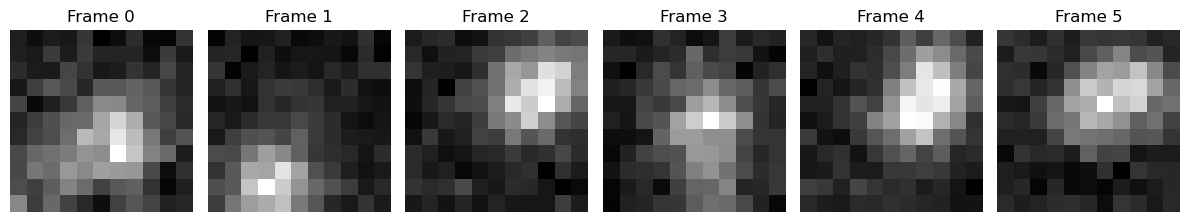

In [20]:
# extract and visualize patches
patches = extract_patches_per_id(frames, trajectories_GT, traj_id=1)
visualize_particle_patches(patches)

## Dection, Localization and Tracking

Auto-computed detection threshold: 368.47 (k=0.7)


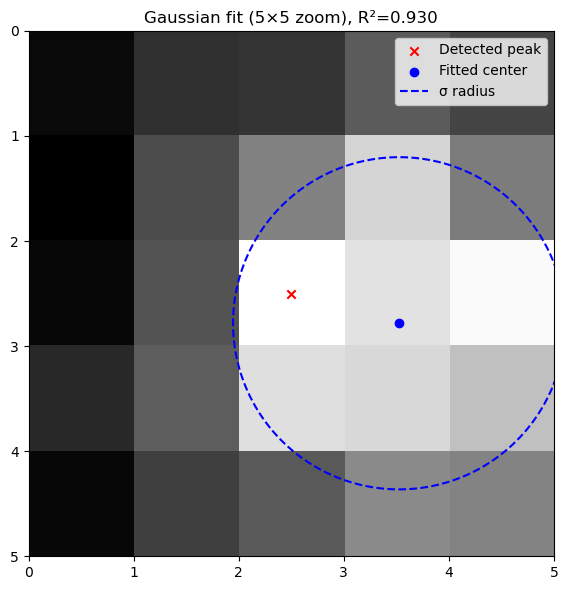

[Frame 0] Poor fit for peak at (73, 114): R-squared = 0.387 (below threshold of 0.5).
[Frame 1] Poor fit for peak at (72, 118): R-squared = 0.492 (below threshold of 0.5).
[Frame 4] Poor fit for peak at (48, 82): R-squared = 0.452 (below threshold of 0.5).
[Frame 5] Poor fit for peak at (11, 96): R-squared = 0.493 (below threshold of 0.5).
[Frame 6] Poor fit for peak at (124, 125): R-squared = 0.215 (below threshold of 0.5).
[Frame 10] Poor fit for peak at (75, 98): R-squared = 0.450 (below threshold of 0.5).
[Frame 11] Poor fit for peak at (93, 64): R-squared = 0.464 (below threshold of 0.5).
[Frame 11] Poor fit for peak at (93, 61): R-squared = 0.440 (below threshold of 0.5).
[Frame 12] Poor fit for peak at (73, 115): R-squared = 0.477 (below threshold of 0.5).
[Frame 12] Poor fit for peak at (71, 118): R-squared = 0.227 (below threshold of 0.5).
[Frame 14] Poor fit for peak at (69, 92): R-squared = 0.405 (below threshold of 0.5).
[Frame 16] Poor fit for peak at (62, 90): R-squared =

In [21]:
# Detect, localize and track particles
(
    trajectories_localization,
    cost_peak2peak,
    assignment_output,
    cost_traj2traj,
) = track(
    frames,
    trajectories_GT,
    mode="localization",

    # detection
    detection_threshold=None,

    # linking
    max_distance=10,
    min_length=5,
    max_gap=0,

    # stitching
    stitch_fragments=False,
    stitch_max_gap=4,
    stitch_base_distance=10.0,
    stitch_kwargs=None,
    verbose_stitching=True,

    # localization quality
    r_squared_threshold=0.5,

    # peak-to-peak assignment
    algo_peak2peak="hungarian",
    cost_func_peak2peak=None,

    # trajectory-to-trajectory assignment
    algo_traj2traj="hungarian",
    cost_func_traj2traj=None,

    # verbosity / visualization
    verbose_loc=True,
    visualization_loc=True,
    verbose_assignment=True,
)

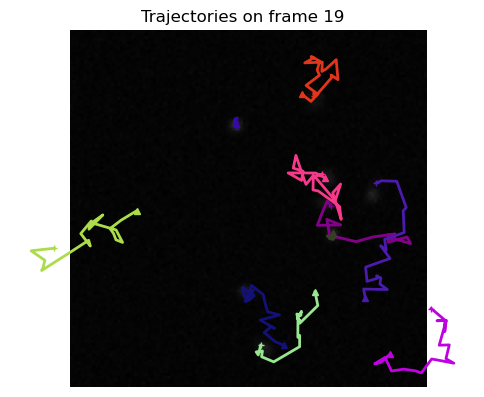

In [22]:
show_trajectories(frames, trajectories_GT, frame_id=simulation_config["nframes"]-1)

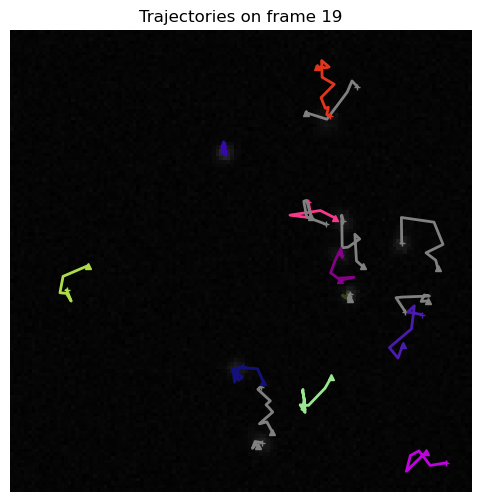

In [23]:
show_trajectories(frames, trajectories_localization, frame_id=simulation_config["nframes"]-1)

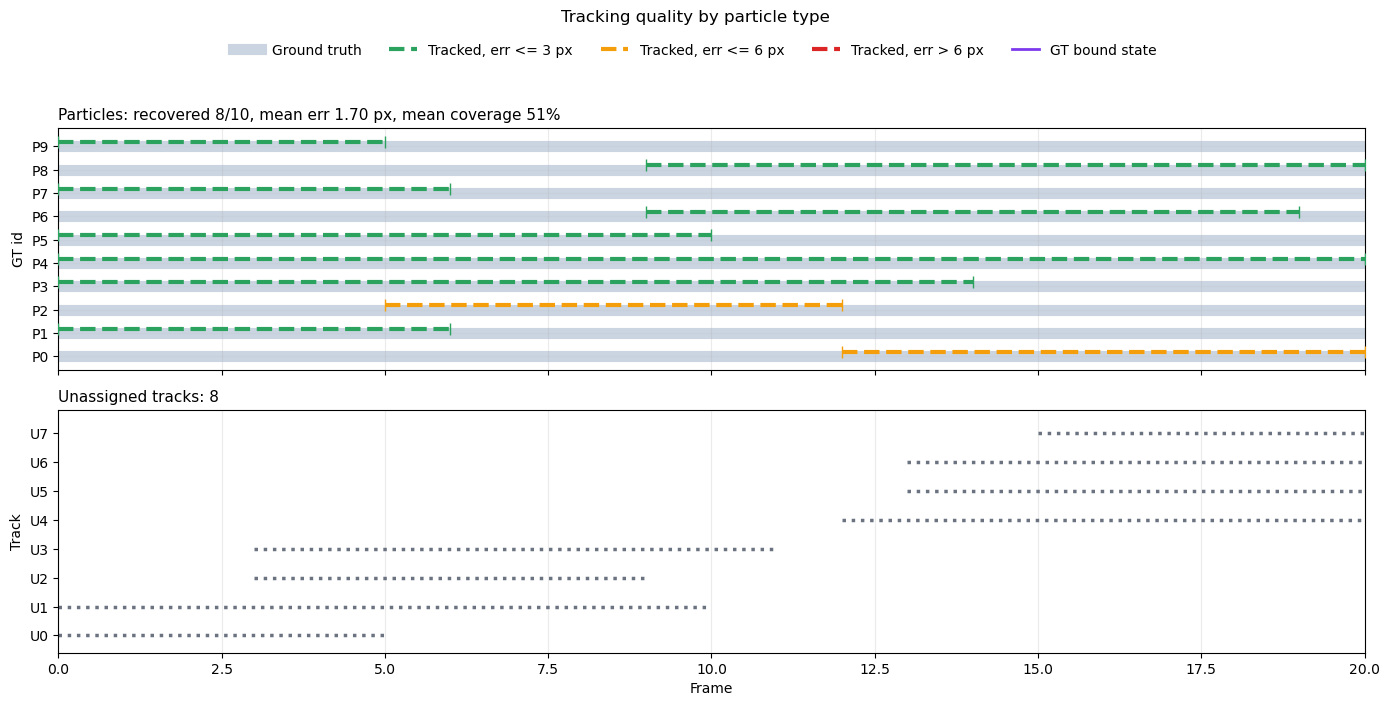

In [24]:
linear_trajectories_visualizer(trajectories_localization, trajectories_GT)

## 3. MSD and D estimation

In [25]:
MSD_list_GT = calculateMSDtrajectories(trajectories_GT)
MSD_list = calculateMSDtrajectories(trajectories_localization)

In [26]:
results = estimateDfromTrajectories(trajectories_localization)

In [27]:
diffusion_results = evaluate_diffusion(trajectories_localization, trajectories_GT, target="localization")

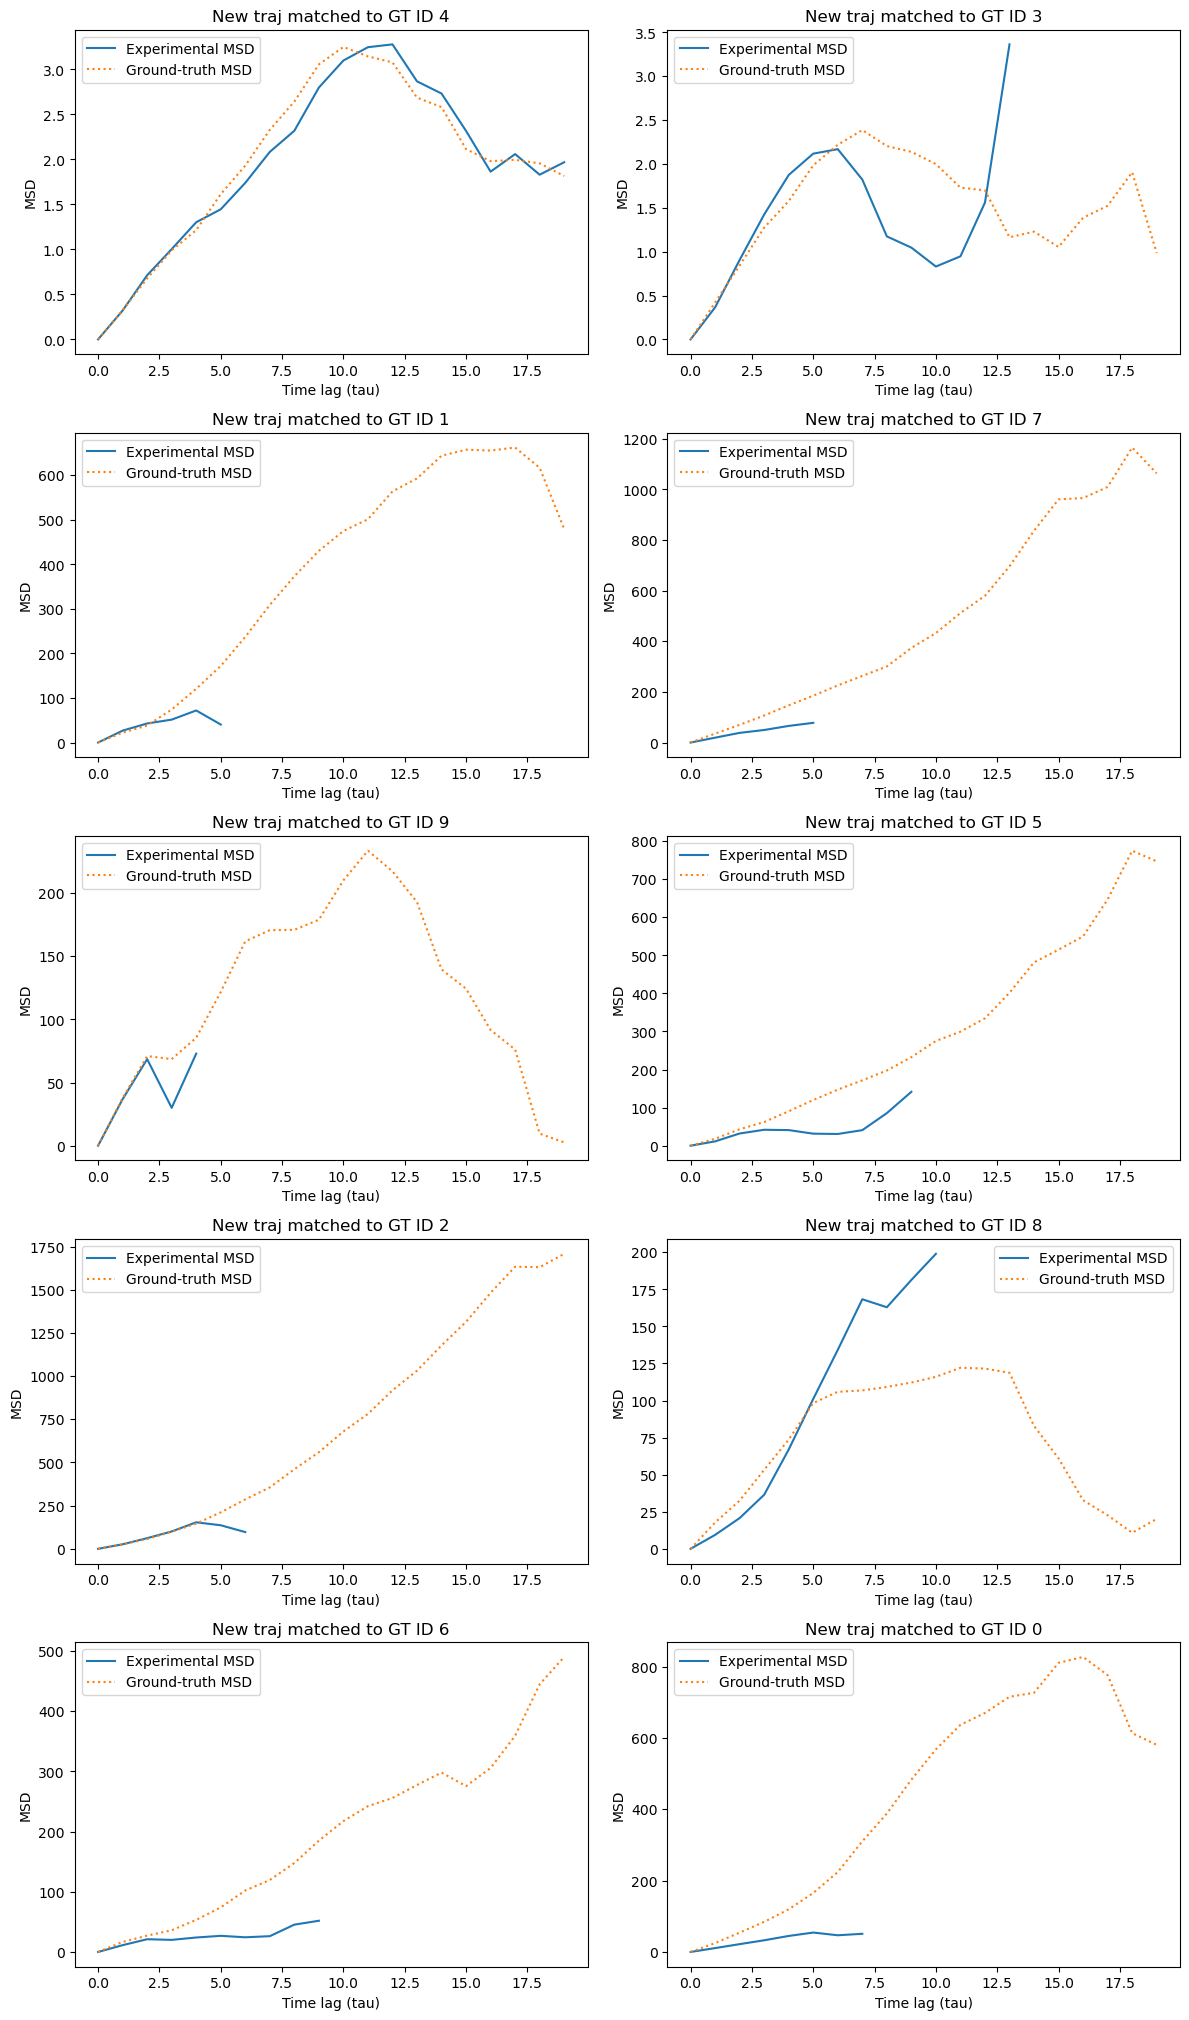

In [28]:
plotMSDvsGT(trajectories_localization, trajectories_GT)